# PPE Classification
## 안전모 / 안전조끼 착용 여부 분류

### 파일명 라벨 규칙
```
파일명 형식: XXXX-HV.jpg
              └──┘ └┘
              번호  라벨
                    │└─ V: vest   (1=착용, 0=미착용)
                    └── H: helmet (1=착용, 0=미착용)

예시)
  0001-00.jpg → helmet=0, vest=0
  0002-10.jpg → helmet=1, vest=0
  0003-01.jpg → helmet=0, vest=1
  0004-11.jpg → helmet=1, vest=1

```v4 (이전)
  학습구조차이 :
    사진 → 모델 1개 → [helmet_prob, vest_prob]
    헬멧이랑 조끼를 동시에 학습
  라벨차이 :
    0001_01.jpg → [0, 1]  두 개 동시에 학습
  저장파일차이 :
    PPE_MobileNetV2.keras      1개
    PPE_MobileNetV2.tflite     1개
v5 (지금)
  학습구조차이 :
    사진 → 헬멧 모델 → helmet_prob
    사진 → 조끼 모델 → vest_prob
    각각 따로 학습
  라벨차이 :
    0001_01.jpg → 헬멧 모델: 0
                → 조끼 모델: 1  따로따로
  저장파일차이 :
    Helmet_MobileNetV2.keras   헬멧 전용
    Vest_MobileNetV2.keras     조끼 전용
    각각 tflite 변환도 따로    총 4개

---
## 1. 모듈 로딩

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
import os
import time
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("NumPy Version      :", np.__version__)
print("TensorFlow Version :", tf.__version__)
print("Matplotlib Version :", plt.matplotlib.__version__)

NumPy Version      : 2.0.2
TensorFlow Version : 2.20.0
Matplotlib Version : 3.10.0


---
## 2. 실행 환경 감지

In [2]:
try:
    import google.colab
    colab = True
    print("환경: Google Colab")
except ImportError:
    colab = False
    print("환경: 로컬 (VS Code / Jupyter)")

환경: Google Colab


---
## 3. 경로 설정

### ★ 로컬 실행 시 여기만 수정하세요

```
예시 (Windows) : C:/Users/본인이름/Desktop/PPE_Dataset
예시 (Mac/Linux): /Users/본인이름/Desktop/PPE_Dataset
```

In [3]:
# ============================================================
#  ★ 로컬 실행 시 아래 두 경로를 본인 환경에 맞게 수정하세요
# ============================================================
LOCAL_DATA_PATH = r'C:/Users/본인이름/Desktop/PPE_Dataset'   # 이미지 폴더
LOCAL_SAVE_PATH = r'C:/Users/본인이름/Desktop/PPE_save'      # 모델 저장 폴더
# ============================================================

if colab:
    # ── Colab: Drive 마운트 후 zip 압축 해제 ──
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive 마운트 완료')

    #!unzip -q -o /content/drive/MyDrive/files/PPE_Dataset.zip -d /content/
    files_path = '/content/drive/MyDrive/프로젝트/Result/Result'
    save_dir   = '/content/drive/MyDrive/files/save/'
else:
    # ── 로컬: 위에서 설정한 경로 사용 ──
    files_path = LOCAL_DATA_PATH
    save_dir   = LOCAL_SAVE_PATH

os.makedirs(save_dir, exist_ok=True)

print(f"\n데이터 경로 : {files_path}")
print(f"저장 경로   : {save_dir}")

# 경로 존재 여부 확인
if not os.path.exists(files_path):
    print(f"\n⚠️  경로를 찾을 수 없어요: {files_path}")
    print("   LOCAL_DATA_PATH 를 올바르게 수정해 주세요.")
else:
    img_count = len(glob.glob(files_path + '/*.*'))
    print(f"\n✅ 경로 확인 완료  ({img_count}개 파일 발견)")

Mounted at /content/drive
Google Drive 마운트 완료

데이터 경로 : /content/drive/MyDrive/프로젝트/Result/Result
저장 경로   : /content/drive/MyDrive/files/save/

✅ 경로 확인 완료  (4069개 파일 발견)


---
## 4. 파일명 파싱 → 라벨 자동 생성

In [4]:
def parse_label_from_filename(filepath):
    """
    파일명에서 helmet / vest 라벨을 파싱한다.

    규칙: XXXX_HV.확장자
      H: 0=헬멧 미착용, 1=헬멧 착용
      V: 0=조끼 미착용, 1=조끼 착용

    Returns: [helmet, vest] 또는 파싱 실패 시 None
    """
    name = os.path.splitext(os.path.basename(filepath))[0]  # 확장자 제거

    if '_' not in name:
        print(f"[건너뜀] '_' 없는 파일명: {os.path.basename(filepath)}")
        return None

    label_str = name.split('_')[-1]  # '_' 뒤 마지막 부분

    if len(label_str) < 2:
        print(f"[건너뜀] 라벨 자리수 부족: {os.path.basename(filepath)}")
        return None

    try:
        helmet = int(label_str[0])
        vest   = int(label_str[1])
    except ValueError:
        print(f"[건너뜀] 숫자 아닌 라벨: {os.path.basename(filepath)}")
        return None

    if helmet not in (0, 1) or vest not in (0, 1):
        print(f"[건너뜀] 라벨은 0 또는 1이어야 함: {os.path.basename(filepath)}")
        return None

    return [helmet, vest]


# 파싱 테스트
test_cases = ['0001_00.jpg', '0002_10.jpg', '0003_01.jpg', '0004_11.jpg']
print("파일명 파싱 테스트")
print("-" * 40)
for tc in test_cases:
    lbl = parse_label_from_filename(tc)
    print(f"  {tc:15s} → helmet={lbl[0]}, vest={lbl[1]}")

파일명 파싱 테스트
----------------------------------------
  0001_00.jpg     → helmet=0, vest=0
  0002_10.jpg     → helmet=1, vest=0
  0003_01.jpg     → helmet=0, vest=1
  0004_11.jpg     → helmet=1, vest=1


In [5]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 5. 전체 이미지 로딩

In [13]:
%%time
IMG_SIZE = 224

# jpg, png, jpeg 모두 탐색
all_files = sorted(
    glob.glob(files_path + '/*.jpg') +
    glob.glob(files_path + '/*.jpeg') +
    glob.glob(files_path + '/*.png')
)
print(f"전체 파일 수: {len(all_files)}개")


def resize_with_padding(img, size=224):
    """
    비율 유지하면서 정사각형으로 변환
    빈 공간은 검은색(0)으로 채움

    예시)
      320×240 입력 → 224×168 리사이즈 → 224×224 캔버스 중앙 배치
    """
    h, w = img.shape[:2]

    # 긴 쪽 기준으로 축소 비율 계산
    scale = size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # 비율 유지 리사이즈
    img_resized = cv2.resize(img, (new_w, new_h))

    # 검은 배경 캔버스에 중앙 배치
    canvas = np.zeros((size, size, 3), dtype=np.uint8)
    top  = (size - new_h) // 2
    left = (size - new_w) // 2
    canvas[top:top+new_h, left:left+new_w] = img_resized

    return canvas


images  = []
labels  = []
skipped = 0

for fpath in all_files:
    lbl = parse_label_from_filename(fpath)
    if lbl is None:
        skipped += 1
        continue

    img = cv2.imread(fpath, cv2.IMREAD_COLOR)
    if img is None:
        print(f"[건너뜀] 이미지 읽기 실패: {os.path.basename(fpath)}")
        skipped += 1
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = resize_with_padding(img, IMG_SIZE)
    images.append(img)
    labels.append(lbl)

images = np.array(images, dtype=np.uint8)
labels = np.array(labels, dtype=np.float32)

print(f"\n로딩 완료 : {len(images)}장  (건너뜀: {skipped}장)")
print(f"images shape : {images.shape}")
print(f"labels shape : {labels.shape}")

전체 파일 수: 4069개

로딩 완료 : 4069장  (건너뜀: 0장)
images shape : (4069, 224, 224, 3)
labels shape : (4069, 2)
CPU times: user 19.4 s, sys: 3.14 s, total: 22.6 s
Wall time: 1min 18s


---
## 6. 클래스 분포 확인

=== 클래스 분포 ===
헬멧  착용(1):  3732장   미착용(0):   337장
조끼  착용(1):   991장   미착용(0):  3078장

=== 조합별 분포 ===
  helmet=0, vest=0  →    236장
  helmet=1, vest=0  →   2842장
  helmet=0, vest=1  →    101장
  helmet=1, vest=1  →    890장


/tmp/ipykernel_1512/495743501.py:26: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/495743501.py:26: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/495743501.py:26: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/495743501.py:26: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/495743501.py:26: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/495743501.py:26: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/495743501.py:26: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

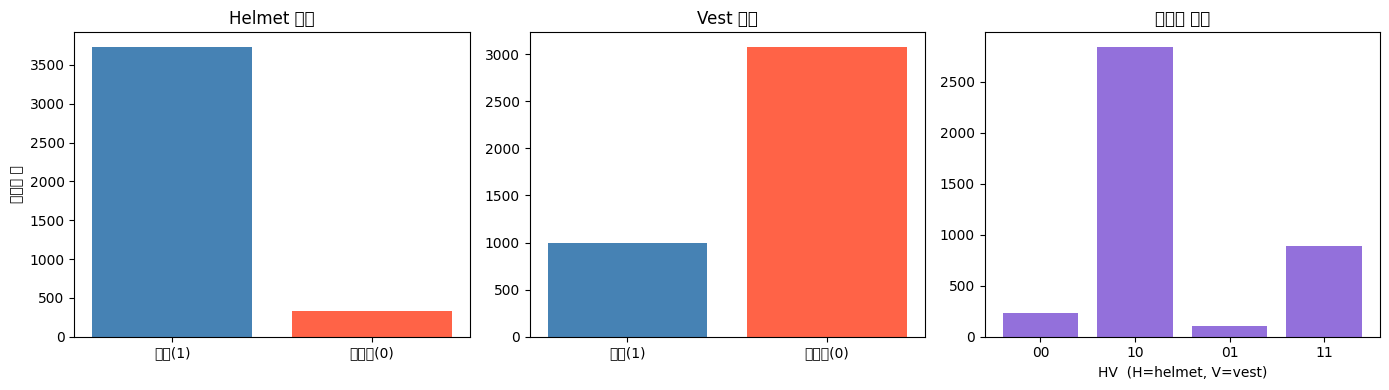

In [14]:
helmet_on  = int(labels[:, 0].sum())
helmet_off = len(labels) - helmet_on
vest_on    = int(labels[:, 1].sum())
vest_off   = len(labels) - vest_on

combos = {'00': 0, '10': 0, '01': 0, '11': 0}
for lbl in labels:
    combos[f"{int(lbl[0])}{int(lbl[1])}"] += 1

print("=== 클래스 분포 ===")
print(f"헬멧  착용(1): {helmet_on:5d}장   미착용(0): {helmet_off:5d}장")
print(f"조끼  착용(1): {vest_on  :5d}장   미착용(0): {vest_off  :5d}장")
print("\n=== 조합별 분포 ===")
for k, v in combos.items():
    print(f"  helmet={k[0]}, vest={k[1]}  →  {v:5d}장")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(['착용(1)', '미착용(0)'], [helmet_on,  helmet_off], color=['steelblue', 'tomato'])
axes[0].set_title('Helmet 분포')
axes[0].set_ylabel('이미지 수')
axes[1].bar(['착용(1)', '미착용(0)'], [vest_on,    vest_off],   color=['steelblue', 'tomato'])
axes[1].set_title('Vest 분포')
axes[2].bar(list(combos.keys()), list(combos.values()), color='mediumpurple')
axes[2].set_title('조합별 분포')
axes[2].set_xlabel('HV  (H=helmet, V=vest)')
plt.tight_layout()
plt.show()

---
## 7. Train / Test 분리

In [15]:
train_data, test_data, train_labels, test_labels = train_test_split(
    images, labels,
    test_size    = 0.2,
    random_state = 128
)
print(f"train_data   : {train_data.shape}")
print(f"train_labels : {train_labels.shape}")
print(f"test_data    : {test_data.shape}")
print(f"test_labels  : {test_labels.shape}")

train_data   : (3255, 224, 224, 3)
train_labels : (3255, 2)
test_data    : (814, 224, 224, 3)
test_labels  : (814, 2)


---
## 7-1. 헬멧 / 조끼 라벨 분리
> 각 모델이 자신의 라벨만 학습하도록 분리

In [16]:
# 헬멧/조끼 라벨 각각 분리
helmet_train_labels = train_labels[:, 0]   # 헬멧만 (N,)
vest_train_labels   = train_labels[:, 1]   # 조끼만 (N,)
helmet_test_labels  = test_labels[:, 0]
vest_test_labels    = test_labels[:, 1]

print(f"헬멧 학습 라벨 shape: {helmet_train_labels.shape}")
print(f"조끼 학습 라벨 shape: {vest_train_labels.shape}")
print(f"헬멧 착용 비율: {helmet_train_labels.mean()*100:.1f}%")
print(f"조끼 착용 비율: {vest_train_labels.mean()*100:.1f}%")

헬멧 학습 라벨 shape: (3255,)
조끼 학습 라벨 shape: (3255,)
헬멧 착용 비율: 92.0%
조끼 착용 비율: 23.5%


---
## 10. 모델 생성 (헬멧 / 조끼 각각)
> 각 모델이 해당 특징에만 집중하도록 분리

In [31]:
def build_model(name):
    """
    헬멧 or 조끼 단일 분류 모델
    변경사항
      1. EfficientNetB0 백본
      2. EfficientNet 전용 전처리 적용
      3. 헤드 Dense(256) + BatchNormalization 추가
    """
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ★ EfficientNetB0 전용 전처리
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)

    base_model = tf.keras.applications.EfficientNetB0(
        weights     = 'imagenet',
        include_top = False,
        input_shape = (IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    x = base_model(x, training=False)

    # ★ 헤드 구조 개선
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name=name)(x)

    return tf.keras.Model(inputs, outputs)

helmet_model = build_model('helmet_output')
vest_model   = build_model('vest_output')

print("헬멧 모델 생성 완료  파라미터:", f"{helmet_model.count_params():,}")
print("조끼  모델 생성 완료  파라미터:", f"{vest_model.count_params():,}")

헬멧 모델 생성 완료  파라미터: 4,411,556
조끼  모델 생성 완료  파라미터: 4,411,556


---
## 11. 모델 컴파일

In [32]:
for m, name in [(helmet_model, '헬멧'), (vest_model, '조끼')]:
    m.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss      = 'binary_crossentropy',
        metrics   = ['binary_accuracy']
    )
    print(f"{name} 모델 컴파일 완료")

헬멧 모델 컴파일 완료
조끼 모델 컴파일 완료


---
## 12. 학습 전 결과 시각화

In [33]:
def Make_Result_Plot(suptitle, data, true_labels, pred_probs, n=10, threshold=0.5):
    """
    true_labels : (N,)  0 or 1
    pred_probs  : (N,)  0.0 ~ 1.0
    """
    size = max(len(data) // n, 1)
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(suptitle, fontsize=14)
    for idx in range(n):
        cnt   = min(idx * size + size // 2, len(data) - 1)
        ax    = axes[idx // 5, idx % 5]
        ax.imshow(data[cnt])
        t     = int(true_labels[cnt])
        p     = float(pred_probs[cnt])
        p_bin = int(p >= threshold)
        color = 'red' if t != p_bin else 'black'
        ax.set_title(f"True={t}  Pred={p_bin}({p:.2f})", fontsize=8, color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 헬멧 학습 전
h_out = helmet_model.predict(test_data)[:, 0]
Make_Result_Plot("Helmet — Before Training", test_data, helmet_test_labels, h_out)

# 조끼 학습 전
v_out = vest_model.predict(test_data)[:, 0]
Make_Result_Plot("Vest — Before Training", test_data, vest_test_labels, v_out)

Output hidden; open in https://colab.research.google.com to view.

---
## 13. 콜백 설정

In [34]:
helmet_saved = os.path.join(save_dir, 'Helmet_MobileNetV2.keras')
vest_saved   = os.path.join(save_dir, 'Vest_MobileNetV2.keras')

def make_callbacks(saved_path):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            saved_path, save_best_only=True,
            monitor='val_binary_accuracy', mode='max', verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            patience             = 10,
            monitor              = 'val_binary_accuracy',
            restore_best_weights = True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience = 5,
            verbose=1
        )
    ]

helmet_callbacks = make_callbacks(helmet_saved)
vest_callbacks   = make_callbacks(vest_saved)
print(f"헬멧 모델 저장 경로: {helmet_saved}")
print(f"조끼  모델 저장 경로: {vest_saved}")

헬멧 모델 저장 경로: /content/drive/MyDrive/files/save/Helmet_MobileNetV2.keras
조끼  모델 저장 경로: /content/drive/MyDrive/files/save/Vest_MobileNetV2.keras


---
## 14. 모델 학습

In [35]:
%%time
print("=" * 40)
print("헬멧 모델 학습 시작")
print("=" * 40)
helmet_history = helmet_model.fit(
    train_data, helmet_train_labels,
    epochs          = 30,
    batch_size      = 32,
    callbacks       = helmet_callbacks,
    validation_data = (test_data, helmet_test_labels)
)

print("\n" + "=" * 40)
print("조끼 모델 학습 시작")
print("=" * 40)
vest_history = vest_model.fit(
    train_data, vest_train_labels,
    epochs          = 30,
    batch_size      = 32,
    callbacks       = vest_callbacks,
    validation_data = (test_data, vest_test_labels)
)

헬멧 모델 학습 시작
Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - binary_accuracy: 0.6431 - loss: 0.6570
Epoch 1: val_binary_accuracy improved from None to 0.94840, saving model to /content/drive/MyDrive/files/save/Helmet_MobileNetV2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/files/save/Helmet_MobileNetV2.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 306ms/step - binary_accuracy: 0.7502 - loss: 0.5024 - val_binary_accuracy: 0.9484 - val_loss: 0.2911 - learning_rate: 1.0000e-04
Epoch 2/30
101/102 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - binary_accuracy: 0.9178 - loss: 0.2363
Epoch 2: val_binary_accuracy improved from 0.94840 to 0.95455, saving model to /content/drive/MyDrive/files/save/Helmet_MobileNetV2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/files/save/Helmet_MobileNetV2.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - binary_accuracy: 0.9355 - loss: 0.2028 - val_binary_accuracy: 0.9545 - val_loss: 0.1601 - learning_rate: 1.0000e-04
Epoch 3/30
101/1

---
## 15. 학습 곡선

/tmp/ipykernel_1512/4274322368.py:23: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/4274322368.py:23: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/4274322368.py:23: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/4274322368.py:23: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.

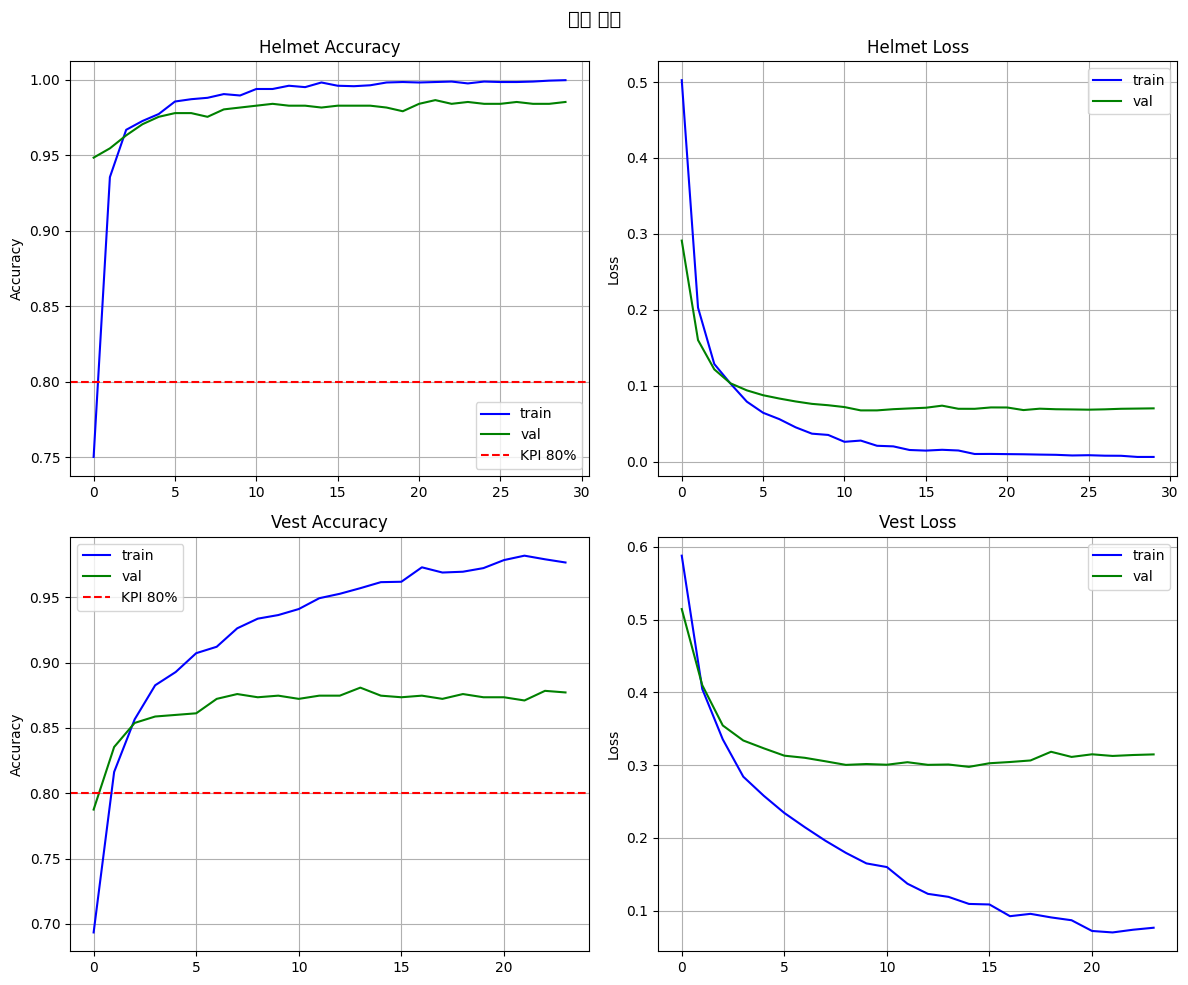

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('학습 곡선', fontsize=14)

for row, (hist, title) in enumerate([
    (helmet_history, 'Helmet'),
    (vest_history,   'Vest')
]):
    axes[row][0].set_title(f'{title} Accuracy')
    axes[row][0].plot(hist.history['binary_accuracy'],     'b', label='train')
    axes[row][0].plot(hist.history['val_binary_accuracy'], 'g', label='val')
    axes[row][0].axhline(0.80, color='r', linestyle='--', label='KPI 80%')
    axes[row][0].legend()
    axes[row][0].grid(True)
    axes[row][0].set_ylabel('Accuracy')

    axes[row][1].set_title(f'{title} Loss')
    axes[row][1].plot(hist.history['loss'],     'b', label='train')
    axes[row][1].plot(hist.history['val_loss'], 'g', label='val')
    axes[row][1].legend()
    axes[row][1].grid(True)
    axes[row][1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

---
## 16. Best 모델 로딩 & 결과 시각화

In [37]:
helmet_best = tf.keras.models.load_model(helmet_saved)
vest_best   = tf.keras.models.load_model(vest_saved)

h_out = helmet_best.predict(test_data)[:, 0]
v_out = vest_best.predict(test_data)[:, 0]

Make_Result_Plot("Helmet — After Training", test_data, helmet_test_labels, h_out)
Make_Result_Plot("Vest   — After Training", test_data, vest_test_labels,   v_out)

Output hidden; open in https://colab.research.google.com to view.

---
## 17. 혼동행렬 & KPI 확인

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


/tmp/ipykernel_1512/1161275682.py:22: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/1161275682.py:22: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1512/1161275682.py:22: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.

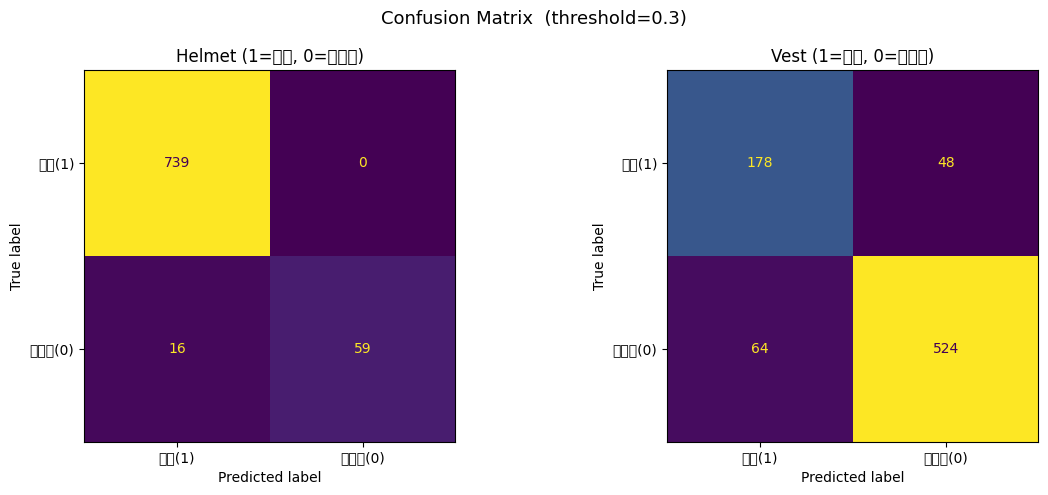

헬멧 정확도: 98.0%   (KPI ≥ 80%)  ✅
조끼 정확도: 86.2%   (KPI ≥ 80%)  ✅


In [38]:
THRESHOLD = 0.3

helmet_pred_prob = helmet_best.predict(test_data)[:, 0]
vest_pred_prob   = vest_best.predict(test_data)[:, 0]

helmet_pred = (helmet_pred_prob >= THRESHOLD).astype(int)
vest_pred   = (vest_pred_prob   >= THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, title in zip(
    axes,
    [helmet_test_labels.astype(int), vest_test_labels.astype(int)],
    [helmet_pred, vest_pred],
    ['Helmet (1=착용, 0=미착용)', 'Vest (1=착용, 0=미착용)']
):
    cm   = confusion_matrix(true, pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(cm, display_labels=['착용(1)', '미착용(0)'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle(f'Confusion Matrix  (threshold={THRESHOLD})', fontsize=13)
plt.tight_layout()
plt.show()

h_acc = (helmet_test_labels.astype(int) == helmet_pred).mean()
v_acc = (vest_test_labels.astype(int)   == vest_pred).mean()
print(f"헬멧 정확도: {h_acc*100:.1f}%   (KPI ≥ 80%)  {'✅' if h_acc>=0.8 else '❌'}")
print(f"조끼 정확도: {v_acc*100:.1f}%   (KPI ≥ 80%)  {'✅' if v_acc>=0.8 else '❌'}")

---
## 오답이미지 모아보기

In [39]:
def show_wrong_predictions(data, true_labels, pred_probs, title='', threshold=0.3, max_show=20):
    """
    true_labels : (N,)  0 or 1  ← 헬멧 or 조끼 각각
    pred_probs  : (N,)  0.0~1.0
    """
    wrong_idx = []
    for i in range(len(data)):
        t = int(true_labels[i])
        p = int(pred_probs[i] >= threshold)
        if t != p:
            wrong_idx.append(i)

    print(f"[{title}] 전체 {len(data)}장 중 오답: {len(wrong_idx)}장")
    print(f"오답률: {len(wrong_idx)/len(data)*100:.1f}%")

    show_idx = wrong_idx[:max_show]
    n_cols = 5
    n_rows = max((len(show_idx) + n_cols - 1) // n_cols, 1)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes = np.array(axes).flatten()
    fig.suptitle(f"{title} 오답 이미지 (총 {len(wrong_idx)}장 중 {len(show_idx)}장)", fontsize=14)

    for ax_idx, i in enumerate(show_idx):
        axes[ax_idx].imshow(data[i])
        t = int(true_labels[i])
        p = float(pred_probs[i])
        axes[ax_idx].set_title(
            f"정답={t}  예측={int(p>=threshold)}({p:.2f})",
            fontsize=8, color='red'
        )
        axes[ax_idx].axis('off')

    for ax_idx in range(len(show_idx), len(axes)):
        axes[ax_idx].axis('off')

    plt.tight_layout()
    plt.show()


# 헬멧 오답
show_wrong_predictions(
    test_data, helmet_test_labels, helmet_pred_prob,
    title='Helmet', threshold=0.3
)

# 조끼 오답
show_wrong_predictions(
    test_data, vest_test_labels, vest_pred_prob,
    title='Vest', threshold=0.3
)

Output hidden; open in https://colab.research.google.com to view.

---
## 18. TFLite 변환
### 18-A. Float32

In [ ]:
# 헬멧 모델
conv_h = tf.lite.TFLiteConverter.from_keras_model(helmet_best)
tflite_helmet = conv_h.convert()
helmet_tflite_path = os.path.join(save_dir, 'Helmet_MobileNetV2.tflite')
with open(helmet_tflite_path, 'wb') as f:
    f.write(tflite_helmet)
print(f"헬멧 TFLite 저장: {helmet_tflite_path}")

# 조끼 모델
conv_v = tf.lite.TFLiteConverter.from_keras_model(vest_best)
tflite_vest = conv_v.convert()
vest_tflite_path = os.path.join(save_dir, 'Vest_MobileNetV2.tflite')
with open(vest_tflite_path, 'wb') as f:
    f.write(tflite_vest)
print(f"조끼  TFLite 저장: {vest_tflite_path}")

### 18-B. INT8 양자화 (Raspberry Pi 5 최적화)

In [ ]:
calib_data = test_data[:100].astype(np.float32)

def representative_dataset():
    for img in calib_data:
        yield [img[np.newaxis, ...]]

def convert_int8(model, saved_path):
    conv = tf.lite.TFLiteConverter.from_keras_model(model)
    conv.optimizations                    = [tf.lite.Optimize.DEFAULT]
    conv.target_spec.supported_ops        = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv.inference_input_type             = tf.int8
    conv.inference_output_type            = tf.int8
    conv.representative_dataset           = representative_dataset
    tflite = conv.convert()
    with open(saved_path, 'wb') as f:
        f.write(tflite)
    print(f"INT8 저장: {saved_path}")

convert_int8(helmet_best, os.path.join(save_dir, 'Helmet_MobileNetV2_INT8.tflite'))
convert_int8(vest_best,   os.path.join(save_dir, 'Vest_MobileNetV2_INT8.tflite'))

---
## 19. 추론 함수 (Raspberry Pi 5 복사 사용)
> `detector.py` 에 그대로 붙여넣어 사용

In [ ]:
def run_ppe_inference(helmet_interp, vest_interp, img_bgr, threshold=0.3):
    """
    Parameters
    ----------
    helmet_interp : 헬멧 TFLite Interpreter (allocate_tensors() 완료)
    vest_interp   : 조끼  TFLite Interpreter (allocate_tensors() 완료)
    img_bgr       : np.ndarray  OpenCV BGR 이미지
    threshold     : float  착용 판정 임계값 (기본 0.5)

    Returns
    -------
    dict {helmet, vest, helmet_prob, vest_prob}
    """
    def infer(interp, img):
        inp = interp.get_input_details()
        out = interp.get_output_details()
        img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_sized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
        img_input = img_sized[np.newaxis, ...]
        interp.set_tensor(inp[0]['index'], img_input)
        interp.invoke()
        return float(interp.get_tensor(out[0]['index'])[0][0])

    h_prob = infer(helmet_interp, img_bgr)
    v_prob = infer(vest_interp,   img_bgr)

    return {
        'helmet'      : bool(h_prob >= threshold),
        'vest'        : bool(v_prob >= threshold),
        'helmet_prob' : h_prob,
        'vest_prob'   : v_prob,
    }


# 동작 확인
helmet_interp = tf.lite.Interpreter(model_content=tflite_helmet)
helmet_interp.allocate_tensors()
vest_interp   = tf.lite.Interpreter(model_content=tflite_vest)
vest_interp.allocate_tensors()

sample_bgr = cv2.cvtColor(test_data[0], cv2.COLOR_RGB2BGR)
result     = run_ppe_inference(helmet_interp, vest_interp, sample_bgr)

print("추론 결과 :", result)
print(f"실제 라벨 : helmet={int(helmet_test_labels[0])}, vest={int(vest_test_labels[0])}")